In [1]:
import pandas as pd
df=pd.read_csv('Dataset2 .csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


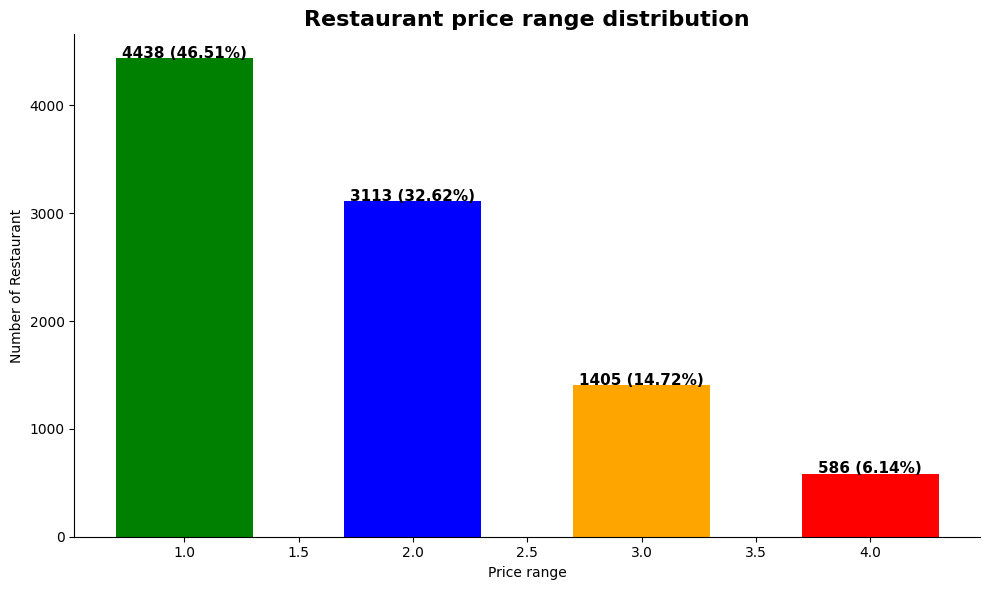

In [2]:
#price range distribution
#create a histogram or bar chart to visualize the distribution of price range among the resturants and calculate percentage of resturant in each price range
import matplotlib.pyplot as plt
import numpy as np
price_counts=df['Price range'].value_counts().sort_index() #count how many resturant are in each category
price_pct=(price_counts/len(df)*100).round(2) #converts to percentage
colors=['green','blue','orange','red']
fig, ax=plt.subplots(figsize=(10,6))
bars=ax.bar(price_counts.index,price_counts.values, color=colors, width=0.6)

for bar, pct in zip(bars, price_pct.values):
    height=bar.get_height()
    ax.text(
       bar.get_x() + bar.get_width() / 2,
       height + 1,
       f'{int(height)} ({pct}%)',  #shows count and percentage
       ha='center', fontsize=11, fontweight='bold')
ax.set_title('Restaurant price range distribution', fontsize=16,fontweight='bold')
ax.set_xlabel('Price range')
ax.set_ylabel('Number of Restaurant')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# DETERMINE THE PERCENTAGE OF RESTAURANT THAT OFFER ONLINE DELIVERY

percentage= (df['Has Online delivery'].value_counts(normalize=True)['Yes']) * 100
print(f"percentage of restaurant offering online delivery:{percentage: 2f}%")

In [ ]:
#COMPARE THE AVERAGE RATING OF RESTAURANTS WITH AND WITHOUT ONLINE DELIVERY
avg_rating=df.groupby('Has Online delivery')['Aggregate rating'].mean().round(2).reset_index()

avg_rating.columns=['Online Delivery','Average rating']
print(avg_rating)


In [ ]:
#ANALYZE THE DISTRIBUTION OF AGGREGATE RATING AND DEYERMINE THE MOST COMMON RATING RANGE 
import numpy as np
import matplotlib.pyplot as plt
bins=[0,1,2,3,4,5]
labels=['0-1','1-2','2-3','3-4','4-5']

df['rating_rate']=pd.cut(df['Aggregate rating'],bins=bins,labels=labels)
rating_counts=df['rating_rate'].value_counts().sort_index()
rating_pct=(rating_counts / len(df)*100).round(2)

print(rating_counts)
print(rating_pct)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(rating_counts.index, rating_counts.values,
              color=['salmon','gold','skyblue','mediumseagreen','violet'],
              edgecolor='white', width=0.6)

# Add count + percentage on top of each bar
for bar, pct in zip(bars, rating_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f'{int(height)}\n({pct}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Restaurant Rating Range Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Rating Range', fontsize=13)
ax.set_ylabel('Number of Restaurants', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
avg_votes=df['Votes'].mean().round(2)
print(f'average number of Votes received by restaurant:{avg_votes}')

In [ ]:
Counts=df['Cuisines'].value_counts()
print(Counts.head(10))

In [ ]:
cuisine_rating=df.groupby('Cuisines')['Aggregate rating'].mean().round(2)
cuisine_rating=cuisine_rating.sort_values(ascending=False)
print(cuisine_rating.head(10))

In [ ]:
#IDENTIFY THERE IS ANY RESTURANT CHAIN PRESENT IN THE DATASET
chain_counts=df['Restaurant Name'].value_counts()
Chains=chain_counts[chain_counts>1]
print(chain_counts)

In [ ]:
chain_restaurant=chain_counts[chain_counts>1].sum()
single_restaurant=chain_counts[chain_counts==1].sum()
total=len(df)

print(f'chain restaurant  :{chain_restaurant}')
print(f'single restaurant :{single_restaurant}')
print(f'total restaurant  :{total}')

In [ ]:
##Analyze the ratings and popularity of different restaurant chains.
chain_counts=df['Restaurant Name'].value_counts()
chains=chain_counts[chain_counts>1].index
df_chains=df[df['Restaurant Name'].isin(chains)]

In [ ]:
chain_analysis = df_chains.groupby('Restaurant Name').agg({
    'Aggregate rating': 'mean',
    'Votes': 'sum',
    'Restaurant Name': 'count'
}).round(2)

chain_analysis.columns = ['Avg_Rating', 'Total_Votes', 'Branches']
chain_analysis = chain_analysis.sort_values('Avg_Rating', ascending=False)
print(chain_analysis.head(10))